In [1]:
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os
import xarray as xr
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pyproj
from scipy.interpolate import griddata
from matplotlib.axes import Axes
from cartopy.mpl.geoaxes import GeoAxes
GeoAxes._pcolormesh_patched = Axes.pcolormesh
from scipy.interpolate import griddata
import cartopy.util as cutil
from scipy.spatial import cKDTree


In [2]:
home_path = os.path.expanduser("~")

path = '/Library/Application Support/MathWorks/MATLAB Add-Ons/Toolboxes/DASH/@optimalSensor'
path2 = '/Library/Mobile Documents/com~apple~CloudDocs/Documents/Documents - MacBook Air/Python/Ice Cores/data/model/ccsm4_last_millennium'
path3 = '/DataFiles'



In [3]:
ds = nc.Dataset(home_path + path3 +"/pr_sfc_Amon_CCSM4_past1000_085001-185012.nc")
tas = nc.Dataset(home_path + path3 +"/tas_sfc_Amon_CCSM4_past1000_085001-185012.nc")
lat = np.array(ds.variables['lat'])
lon = np.array(ds.variables['lon'])
tempPrecip = np.array(ds.variables['pr'])
tempTemp = np.array(tas.variables['tas'])

/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_79011/4271342169.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lat = np.array(ds.variables['lat'])
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_79011/4271342169.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lon = np.array(ds.variables['lon'])
/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_79011/4271342169.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy k

In [4]:
era5 = nc.Dataset(home_path + path3 + "/data.nc")
firstMask = era5.variables['t2m']
tempMask = np.roll(firstMask, 1800, axis=2)
latInd = np.array(pd.read_csv(home_path + path3 +'/latInd.csv'))
erLat = era5.variables['latitude']
erLon = era5.variables['longitude']

In [5]:
temp = np.zeros([1001, 192, 288])
precip = np.zeros([1001, 192, 288])

for i in range(1001):
    temp[i] = np.mean(tempTemp[i*12:(i+1)*12], axis=0)
    precip[i] = np.mean(tempPrecip[i*12:(i+1)*12], axis=0) * 31536000





tempRegrid = np.zeros([32, 3600])
secondRegrid = np.zeros([32, 7200])


i = 0
for item in latInd:
    tempRegrid[i, :] = tempMask[0, item[0]]
    i = i + 1


for i in range(32):
    secondRegrid[i, :7198] = np.dstack((tempRegrid[i, :-1], tempRegrid[i, :-1] + np.diff(tempRegrid[i]) / 2.0)).ravel()




regrid = secondRegrid[:, ::25]



latLand = np.zeros([5794])
lonLand = np.zeros([5794])
prLand = np.zeros([5794, 1001])
tasLand = np.zeros([5794, 1001])

gridCount = 0

for i in range(32):
    for j in range(288):
        if regrid[i, j] > 0:
            latLand[gridCount] = lat[i]
            lonLand[gridCount] = lon[j]
            prLand[gridCount] = precip[:, i, j]
            tasLand[gridCount] = temp[:, i, j]
            gridCount = gridCount + 1



In [6]:
quad = np.array(pd.read_csv(home_path + path + '/WAIS_BS_MRE_TEM.csv'))[:5793, 0]

In [7]:
print(np.argmax(quad))

1863


In [8]:
sortedQuad = np.sort(quad)
rankQuad = np.argsort(quad)
print(rankQuad[-2])

5764


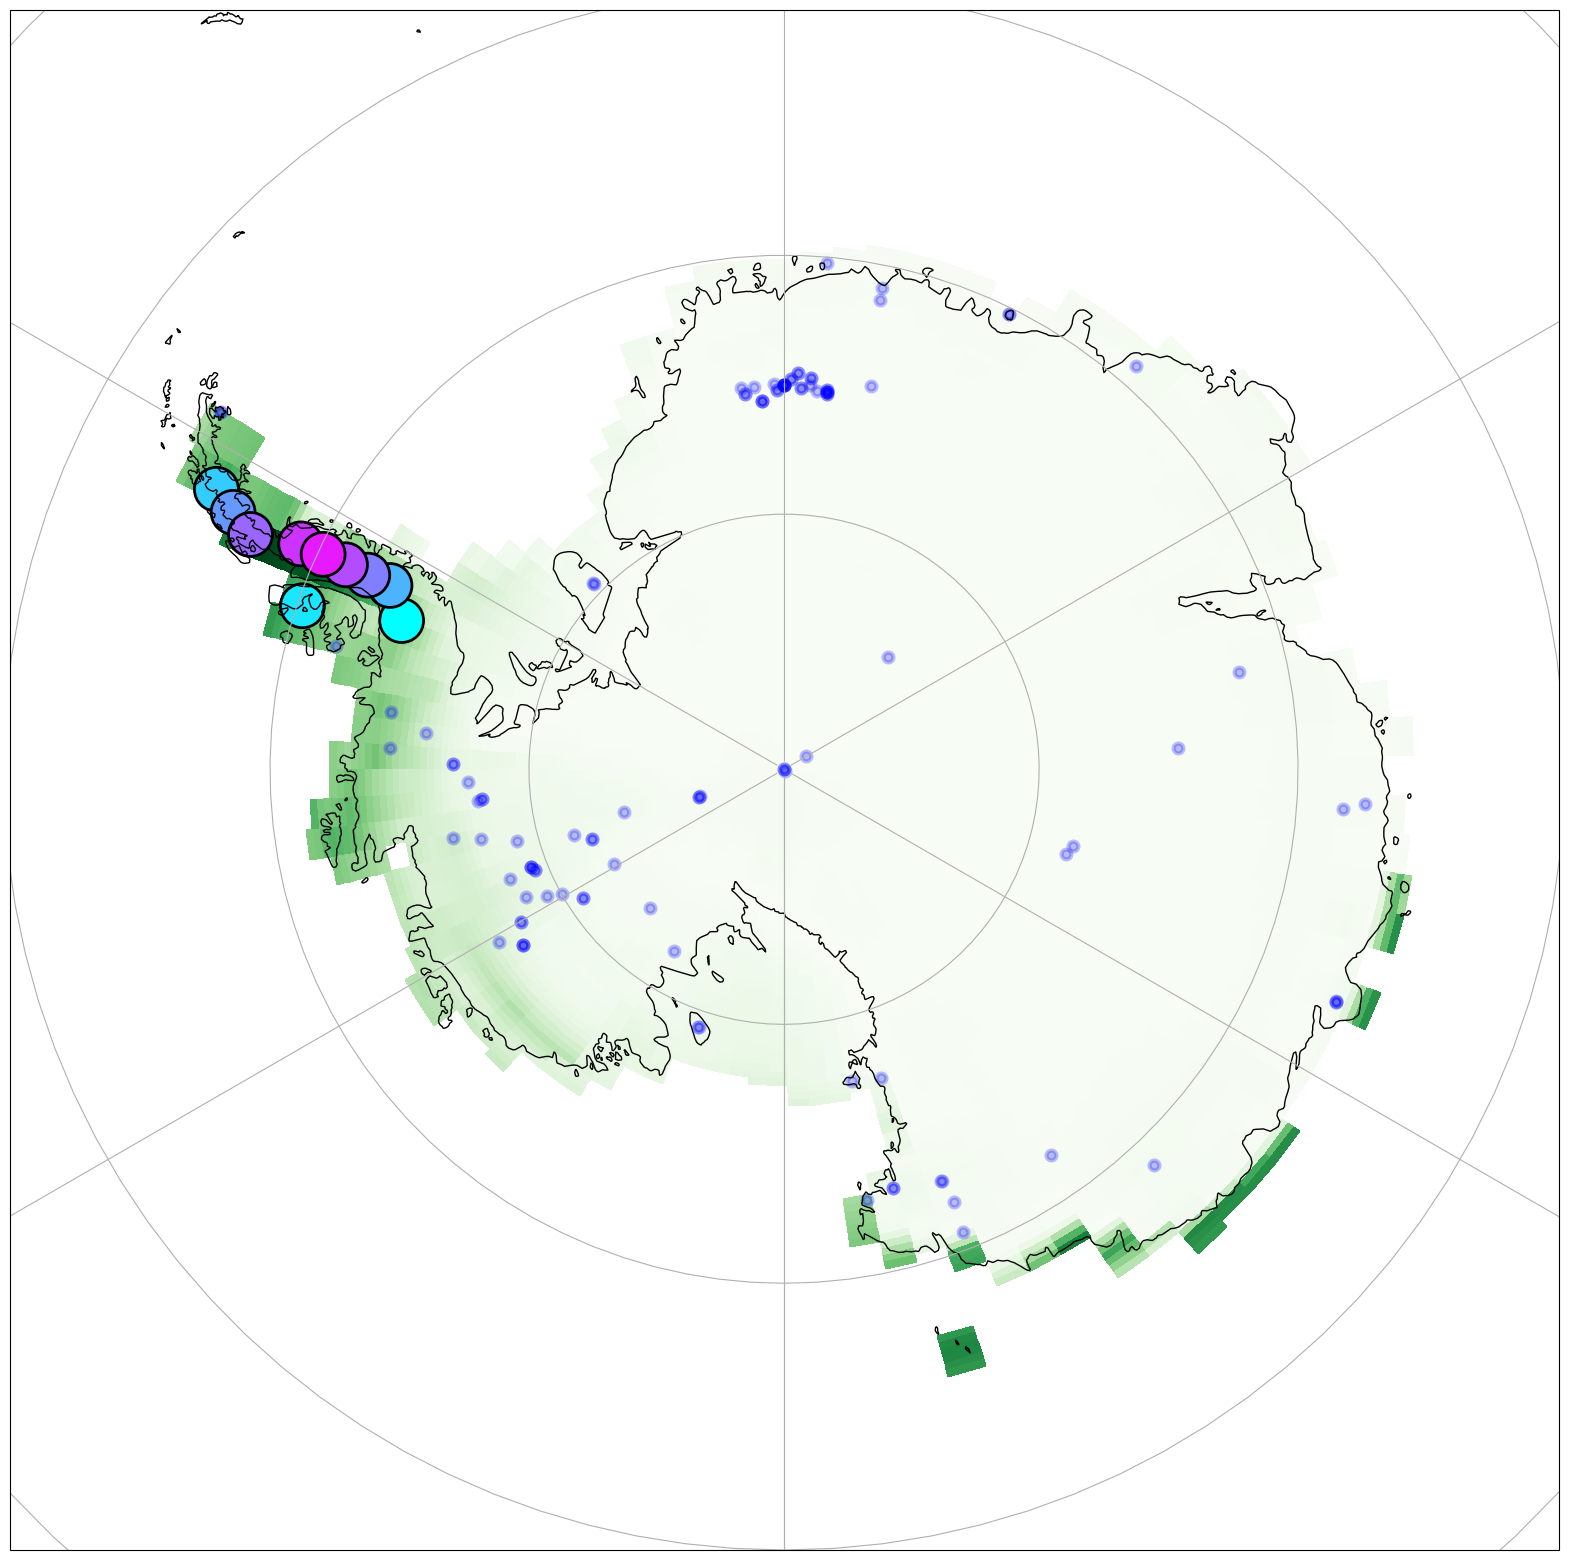

In [52]:
lon_grid = np.linspace(min(lonLand[:5793]), max(lonLand[:5793]), 100)
lat_grid = np.linspace(min(latLand[:5793]), max(latLand[:5793]), 100)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

n = 10



rank = [5680, 5491, 5597, 5345, 5745, 5189, 5779, 5020, 5786, 5486, 4837]

rank.reverse()

topLats = np.zeros([n])
topLons = np.zeros([n])

t = np.arange(n)


#ACCUM
for i in range(n):
    topLats[i] = latLand[rank[i]-1]
    topLons[i] = lonLand[rank[i]-1]

quad = np.array(pd.read_csv(home_path + path + '/AP_BS_MME_TEM_test.csv'))[:5793, 0]
#quad = np.array(pd.read_csv(home_path + path3 + '/CON_MRE_temp_accumR.csv'))[:5793, 0]

sites = np.array(pd.read_csv(home_path + path3 + '/Sites.csv'))
for i in range(len(sites[:, 1])):
    if sites[i, 1] == 161.64:
        sites[i, 1] = -161.64

# Build KD-tree of known points
tree = cKDTree(np.column_stack((lonLand[:5793], latLand[:5793])))

# Flatten the grid for querying
grid_points = np.column_stack((lon_mesh.ravel(), lat_mesh.ravel()))

# Query distance to the nearest original point
distances, _ = tree.query(grid_points)
distance_threshold = 1.0  # adjust based on spacing

# Reshape back to grid
distance_mask = distances.reshape(lon_mesh.shape) > distance_threshold

# Interpolate
grid_values = griddata((lonLand[:5793], latLand[:5793]), quad, (lon_mesh, lat_mesh), method='linear')

# Replace NaNs and apply mask
#grid_values = np.nan_to_num(grid_values, nan=0.0)
grid_values[distance_mask] = np.nan

newLonMesh = cutil.add_cyclic_point(lon_mesh)
newLatMesh = cutil.add_cyclic_point(lat_mesh)
newGridVals = cutil.add_cyclic_point(grid_values)

#quad = np.sqrt(mreTempNorm ** 2 + mmeTempNorm **2 + mreAccumNorm ** 2 + mmeAccumNorm ** 2)
#quad = np.sqrt(mreTempNorm ** 2 + mmeTempNorm **2 + mreAccumNorm ** 2 + mmeAccumNorm ** 2 + mreTempNormB ** 2 + mmeTempNormB **2 + mreAccumNormB ** 2 + mmeAccumNormB ** 2)

ax = plt.axes(projection=ccrs.SouthPolarStereo())
#ax.set_extent([-200, -160, -90, -75], ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())

ax.gridlines()

plt.rcParams['figure.figsize'] = [20, 20]

#plt.scatter(lonLand[:5793], latLand[:5793], c=quad, s=300, cmap=plt.cm.Greens, linewidth=3, alpha=0.75, zorder=1, transform=ccrs.PlateCarree())
#plt.pcolormesh(newLonMesh, newLatMesh, newGridVals, transform=ccrs.PlateCarree(), cmap=plt.cm.Greens)
plt.pcolormesh(lon_mesh, lat_mesh, grid_values, zorder=0, transform=ccrs.PlateCarree(), cmap=plt.cm.Greens)
plt.scatter(sites[:, 1], sites[:, 0], c='blue', s=50, linewidth=3, alpha=0.25, zorder=1, transform=ccrs.PlateCarree())


#plt.title("Accumulation: Top 10 sites")

ax.coastlines()
plt.scatter(topLons, topLats, c=t, s=1000, linewidth=2, edgecolors='black', alpha=1, cmap=plt.cm.cool, vmin=0, vmax=10, zorder=1, transform=ccrs.PlateCarree())

#plt.legend(fontsize=29)
#plt.scatter(crLon, crLat, c='yellow', s=500, transform=ccrs.PlateCarree())
plt.show()
